In [1]:
import sys
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [2]:
import random
import statistics

from typing import Dict, Optional
import matplotlib.pyplot as plt

## Default

Target 4 bombs: slope = 0.4999, intercept = 3.50
Target 5 bombs: slope = 0.6191, intercept = 4.33


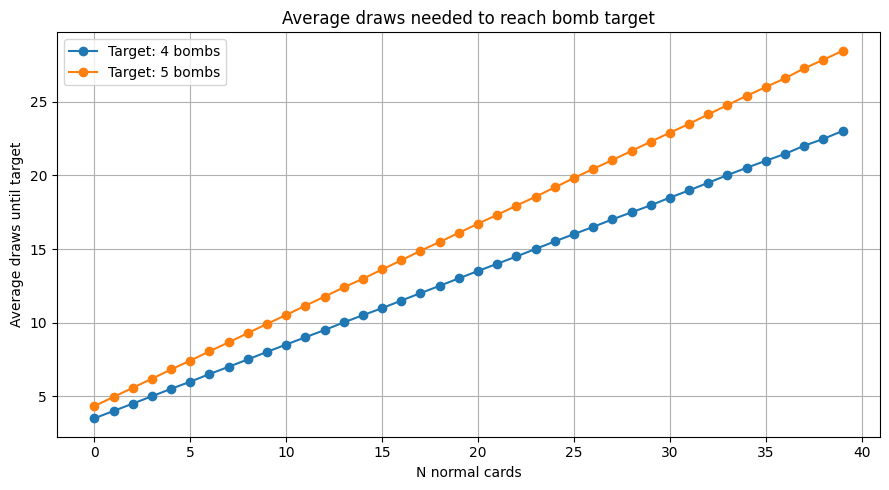

In [30]:
import random
from statistics import mean, median

def one_run(n_normal: int, n_bombs=6, n_double=2, target_bombs: int = 5) -> int:
    """
    Deck:
      - 6 bomb cards worth 1 bomb
      - 2 double-bomb cards worth 2 bombs
      - n_normal normal cards worth 0 bombs

    Returns number of draws until bomb count >= target_bombs.
    """
    deck = [1] * n_bombs + [2] * n_double + [0] * n_normal
    random.shuffle(deck)

    bombs = 0
    for draws, card_value in enumerate(deck, start=1):
        bombs += card_value
        if bombs >= target_bombs:
            return draws

    return len(deck)


def simulate(
    n_values,
    target_bombs: int = 5,
    n_bombs=6, 
    n_double=2,
    runs: int = 100_000,
    seed: int = 1,
):
    random.seed(seed)

    results = []

    for n in n_values:
        draws = [one_run(n, target_bombs=target_bombs, n_bombs=n_bombs, n_double=n_double) for _ in range(runs)]
        results.append({
            "N normal cards": n,
            "target bombs": target_bombs,
            "average draws": mean(draws),
            "median draws": median(draws),
            "p10 draws": sorted(draws)[int(0.10 * runs)],
            "p90 draws": sorted(draws)[int(0.90 * runs)],
            "min draws": min(draws),
            "max draws": max(draws),
        })

    return results


import matplotlib.pyplot as plt

def plot_results(results_by_target):
    plt.figure(figsize=(9, 5))

    for target_bombs, results in results_by_target.items():
        x = [row["N normal cards"] for row in results]
        y = [row["average draws"] for row in results]

        plt.plot(x, y, marker="o", label=f"Target: {target_bombs} bombs")

    plt.xlabel("N normal cards")
    plt.ylabel("Average draws until target")
    plt.title("Average draws needed to reach bomb target")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

import numpy as np

def compute_slope(results):
    x = np.array([row["N normal cards"] for row in results])
    y = np.array([row["average draws"] for row in results])

    # Fit line y = a*x + b
    a, b = np.polyfit(x, y, 1)
    return a, b


if __name__ == "__main__":
    n_values = range(0, 40, 1)

    results_4 = simulate(n_values, target_bombs=4, n_bombs=5, n_double=1)
    results_5 = simulate(n_values, target_bombs=5, n_bombs=5, n_double=1)

    # Compute slopes
    slope_4, intercept_4 = compute_slope(results_4)
    slope_5, intercept_5 = compute_slope(results_5)

    print(f"Target 4 bombs: slope = {slope_4:.4f}, intercept = {intercept_4:.2f}")
    print(f"Target 5 bombs: slope = {slope_5:.4f}, intercept = {intercept_5:.2f}")

    plot_results({
        4: results_4,
        5: results_5,
    })

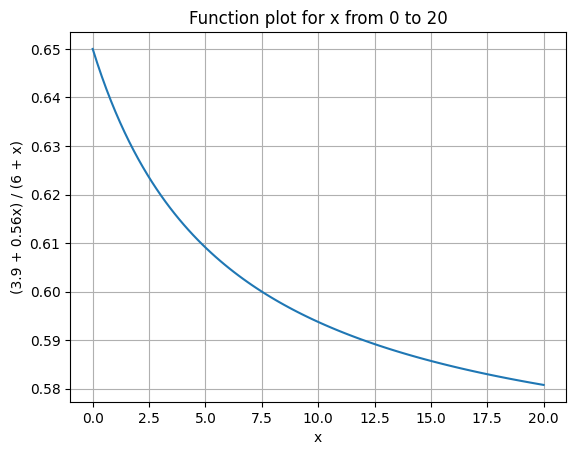

In [22]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 20, 100)
y = (3.9 + 0.56 * x) / (6 + x)

plt.figure()
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("(3.9 + 0.56x) / (6 + x)")
plt.title("Function plot for x from 0 to 20")
plt.grid(True)
plt.show()